# T3 Churn definition

**Goal T3.** Define the activity event and the inactivity gap that make a player "churned", with Kaplan-Meier curves for 14, 30 and 60-day gaps and the return-after-dormancy rates, and propose the threshold for sign-off.

**Data.** The S3 data lake (`org/40-gold`). The activity event is **a day with at least one bet**, any wallet, from `gld_player_gaming_daily` (which has `brand_id` on every row; `gld_player_signals_daily` has no `brand_id` before July 2026).


In [1]:
import datetime as dt
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "eda" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "features"))
import daily_cache

BRAND = 64                    # brandId, or "basel" for every brand
THRESHOLDS = (14, 30, 60)     # candidate inactivity gaps, in days
MAX_INACTIVE_DAYS = 120
FOLLOW_UP_DAYS = 60           # a return counts if it happens within this many days
BURN_IN_DAYS = 90             # new players: first bet at least this long after the history starts
LOOKBACK_DAYS = 30            # population of a cutoff: a bet in the 30 days up to it (as in the features)
OUT = PROJECT_ROOT / f"data/03_output/churn_definition/brand{BRAND}"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 200)

## 1. Data: daily activity



In [2]:
t0 = time.time()
daily_cache.build("activity")
days = daily_cache.read("activity", BRAND, columns="tenant_id, player_id, day")
days["day"] = pd.to_datetime(days["day"]).dt.date
HISTORY_START, OBS_END = days["day"].min(), days["day"].max()
n_players = days[["tenant_id", "player_id"]].drop_duplicates().shape[0]
print(f"brand {BRAND}: {n_players:,} players, {len(days):,} player-days with a bet, "
      f"{HISTORY_START} to {OBS_END} ({time.time() - t0:.0f}s)")

gold activity: 554 day(s) (2025-04-01 to 2026-10-06, 16,186,569 player-days) in 67s
brand 64: 126,581 players, 1,640,224 player-days with a bet, 2025-04-01 to 2026-10-06 (71s)


## 2. Dormancy spells



In [3]:
def spells(days: pd.DataFrame, obs_end: dt.date) -> pd.DataFrame:
    d = days.sort_values(["tenant_id", "player_id", "day"]).reset_index(drop=True)
    day = pd.to_datetime(d["day"]).to_numpy("datetime64[D]").astype(np.int64)
    same_player = ((d["tenant_id"].to_numpy()[1:] == d["tenant_id"].to_numpy()[:-1])
                   & (d["player_id"].to_numpy()[1:] == d["player_id"].to_numpy()[:-1]))
    nxt = np.append(np.where(same_player, day[1:], -1), -1)
    closed = nxt >= 0
    end = np.datetime64(obs_end, "D").astype(np.int64)
    return pd.DataFrame({"day": day, "length": np.where(closed, nxt - day - 1, end - day), "closed": closed})

S = spells(days, OBS_END)
print(f"{len(S):,} spells, {(S['length'] > 0).mean():.1%} with at least one silent day, {(~S['closed']).sum():,} still open")

1,640,224 spells, 43.0% with at least one silent day, 126,581 still open


## 3. Probability of betting again, by days of silence

For each `d` from 1 to 120: of the spells that reached `d` silent days, the share where the player bet again within the next 60 days. Only spells that reached day `d` at least 60 days before the end of the data count, so every point has the same chance to see a return.

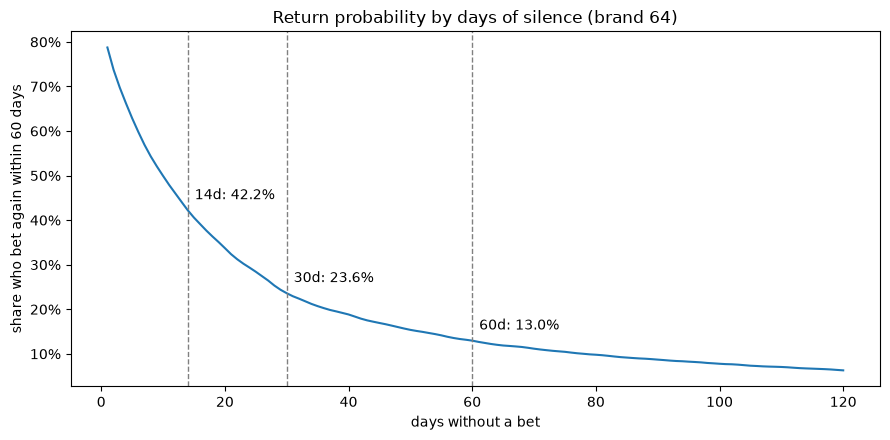

,days_inactive,spells,returned,return_rate
6,7,304593,173306,0.568976
13,14,219608,92698,0.422107
20,21,182317,59002,0.323623
29,30,155558,36716,0.236028
44,45,137130,23203,0.169204
59,60,126332,16372,0.129595
89,90,111670,9716,0.087006
119,120,101295,6373,0.062915


In [4]:
def return_by_inactivity(s: pd.DataFrame, obs_end: dt.date) -> pd.DataFrame:
    end = np.datetime64(obs_end, "D").astype(np.int64)
    day, length, closed = s["day"].to_numpy(), s["length"].to_numpy(), s["closed"].to_numpy()
    rows = []
    for d in range(1, MAX_INACTIVE_DAYS + 1):
        eligible = (length >= d) & (day + d <= end - FOLLOW_UP_DAYS)
        back = eligible & closed & (length - d < FOLLOW_UP_DAYS)
        n = int(eligible.sum())
        rows.append({"days_inactive": d, "spells": n, "returned": int(back.sum()), "return_rate": back.sum() / n if n else np.nan})
    return pd.DataFrame(rows)

curve = return_by_inactivity(S, OBS_END)
curve.to_csv(OUT / "return_by_inactivity.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(curve["days_inactive"], curve["return_rate"], color="tab:blue")
for n in THRESHOLDS:
    r = curve.loc[curve["days_inactive"] == n, "return_rate"].iloc[0]
    ax.axvline(n, color="grey", linestyle="--", linewidth=1)
    ax.annotate(f"{n}d: {r:.1%}", (n, r), textcoords="offset points", xytext=(5, 8))
ax.set_xlabel("days without a bet"); ax.set_ylabel(f"share who bet again within {FOLLOW_UP_DAYS} days")
ax.set_title(f"Return probability by days of silence (brand {BRAND})")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
fig.tight_layout(); fig.savefig(OUT / "return_by_inactivity.png", dpi=120); plt.show()
curve[curve["days_inactive"].isin([7, 14, 21, 30, 45, 60, 90, 120])]

## 4. Return rate after 14, 30 and 60 days of silence

- **Raw**: every spell that reached the threshold; an open one counts as no return.
- **Fair**: the same as section 3 (return within 60 days, same follow-up for every spell).

In [5]:
rows = []
for n in THRESHOLDS:
    reached = S[S["length"] >= n]
    fair = curve.loc[curve["days_inactive"] == n].iloc[0]
    rows.append({"threshold_days": n, "spells": len(reached), "returned_ever": int(reached["closed"].sum()),
                 "still_dormant": int((~reached["closed"]).sum()), "return_rate_raw": reached["closed"].mean(),
                 f"return_rate_fair_{FOLLOW_UP_DAYS}d": fair["return_rate"], "fair_spells": int(fair["spells"])})
dormancy = pd.DataFrame(rows)
dormancy.to_csv(OUT / "return_after_dormancy.csv", index=False)
dormancy.style.format({"spells": "{:,}", "returned_ever": "{:,}", "still_dormant": "{:,}", "fair_spells": "{:,}",
                       "return_rate_raw": "{:.1%}", f"return_rate_fair_{FOLLOW_UP_DAYS}d": "{:.1%}"}).hide(axis="index")

threshold_days,spells,returned_ever,still_dormant,return_rate_raw,return_rate_fair_60d,fair_spells
14,"240,862","125,569","115,293",52.1%,42.2%,"219,608"
30,"170,999","60,754","110,245",35.5%,23.6%,"155,558"
60,"135,848","32,910","102,938",24.2%,13.0%,"126,332"


## 5. Kaplan-Meier: playing lifetime of new players, per threshold

Lifetime = days from the first to the last bet. The churn is confirmed when the silence after the last bet reaches the threshold; otherwise the player is censored (still possibly playing)

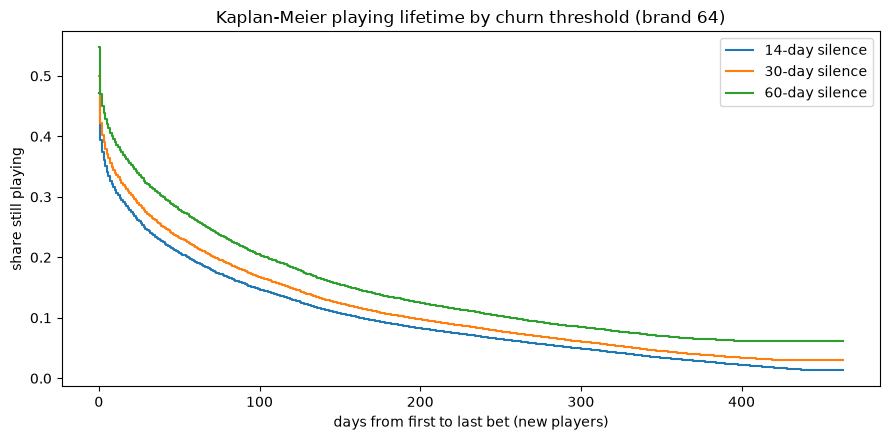

threshold_days,new_players,confirmed_churns,censored_share,median_lifetime_days
14,"66,390","59,793",9.9%,0
30,"66,390","56,068",15.5%,1
60,"66,390","50,225",24.3%,1


In [6]:
life = days.groupby(["tenant_id", "player_id"])["day"].agg(first="min", last="max")
life = life[pd.to_datetime(life["first"]) >= pd.Timestamp(HISTORY_START + dt.timedelta(days=BURN_IN_DAYS))]
duration = (pd.to_datetime(life["last"]) - pd.to_datetime(life["first"])).dt.days
silence = (pd.Timestamp(OBS_END) - pd.to_datetime(life["last"])).dt.days

fig, ax = plt.subplots(figsize=(9, 4.5))
rows = []
for n in THRESHOLDS:
    event = silence >= n
    km = KaplanMeierFitter().fit(duration, event_observed=event, label=f"{n}-day silence")
    km.plot_survival_function(ax=ax, ci_show=False)
    rows.append({"threshold_days": n, "new_players": len(life), "confirmed_churns": int(event.sum()),
                 "censored_share": 1 - event.mean(), "median_lifetime_days": km.median_survival_time_})
ax.set_xlabel("days from first to last bet (new players)"); ax.set_ylabel("share still playing")
ax.set_title(f"Kaplan-Meier playing lifetime by churn threshold (brand {BRAND})")
fig.tight_layout(); fig.savefig(OUT / "km_lifetime.png", dpi=120); plt.show()
km_table = pd.DataFrame(rows)
km_table.to_csv(OUT / "km_lifetime.csv", index=False)
km_table.style.format({"new_players": "{:,}", "confirmed_churns": "{:,}", "censored_share": "{:.1%}",
                       "median_lifetime_days": "{:.0f}"}).hide(axis="index")

## 6. Churn rate by monthly cutoff



/tmp/ipykernel_403290/3509471286.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  first_cut = (pd.Timestamp(HISTORY_START) + pd.Timedelta(days=LOOKBACK_DAYS)).to_period("M").to_timestamp() + pd.offsets.MonthBegin(1)
/tmp/ipykernel_403290/3509471286.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  players = d[(d["day"] > cut - pd.Timedelta(days=LOOKBACK_DAYS)) & (d["day"] <= cut)][["tenant_id", "player_id"]].drop_duplicates()
/tmp/ipykernel_403290/3509471286.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please u

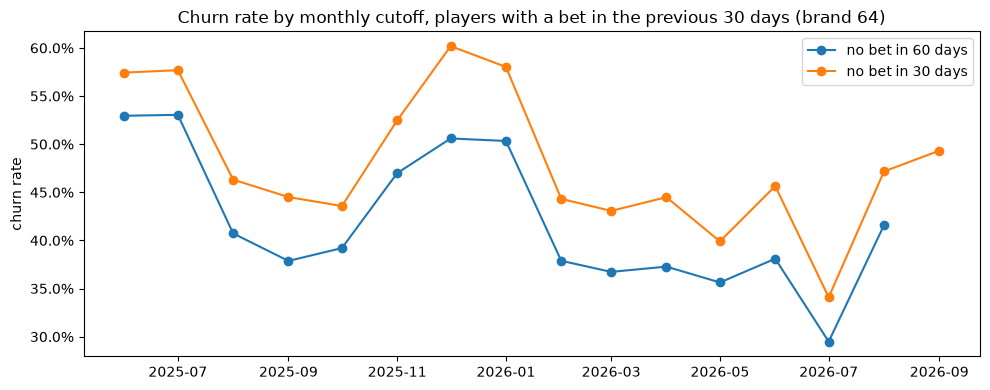

cutoff,players,churn_30d,churn_60d
2025-06-01,"34,106",57.4%,53.0%
2025-07-01,"27,427",57.7%,53.0%
2025-08-01,"19,120",46.3%,40.7%
2025-09-01,"18,433",44.5%,37.9%
2025-10-01,"19,279",43.6%,39.2%
2025-11-01,"22,163",52.5%,47.0%
2025-12-01,"17,727",60.2%,50.6%
2026-01-01,"14,569",58.0%,50.3%
2026-02-01,"11,878",44.3%,37.9%
2026-03-01,"12,622",43.1%,36.7%


In [7]:
d = days.assign(day=pd.to_datetime(days["day"]))
first_cut = (pd.Timestamp(HISTORY_START) + pd.Timedelta(days=LOOKBACK_DAYS)).to_period("M").to_timestamp() + pd.offsets.MonthBegin(1)
rows = []
for cut in pd.date_range(first_cut, pd.Timestamp(OBS_END), freq="MS"):
    players = d[(d["day"] > cut - pd.Timedelta(days=LOOKBACK_DAYS)) & (d["day"] <= cut)][["tenant_id", "player_id"]].drop_duplicates()
    row = {"cutoff": cut.date(), "players": len(players)}
    for h in (30, 60):
        if cut + pd.Timedelta(days=h) > pd.Timestamp(OBS_END):
            row[f"churn_{h}d"] = np.nan
            continue
        after = d[(d["day"] > cut) & (d["day"] <= cut + pd.Timedelta(days=h))][["tenant_id", "player_id"]].drop_duplicates()
        row[f"churn_{h}d"] = 1 - len(players.merge(after, on=["tenant_id", "player_id"])) / len(players)
    rows.append(row)
monthly = pd.DataFrame(rows)
monthly.to_csv(OUT / "monthly_churn.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["cutoff"], monthly["churn_60d"], marker="o", label="no bet in 60 days")
ax.plot(monthly["cutoff"], monthly["churn_30d"], marker="o", label="no bet in 30 days")
ax.set_ylabel("churn rate"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title(f"Churn rate by monthly cutoff, players with a bet in the previous 30 days (brand {BRAND})")
ax.legend(); fig.tight_layout(); fig.savefig(OUT / "monthly_churn.png", dpi=120); plt.show()
monthly.style.format({"players": "{:,}", "churn_30d": "{:.1%}", "churn_60d": "{:.1%}"}, na_rep="not observable yet").hide(axis="index")

## 7. Reference: every brand

The same return rates for all brands together, to see whether brand 64 behaves like the rest.

In [8]:
all_days = daily_cache.read("activity", "basel", columns="tenant_id, player_id, day")
all_days["day"] = pd.to_datetime(all_days["day"]).dt.date
all_curve = return_by_inactivity(spells(all_days, OBS_END), OBS_END)
reference = (curve.set_index("days_inactive")[["return_rate"]].rename(columns={"return_rate": f"brand {BRAND}"})
             .join(all_curve.set_index("days_inactive")[["return_rate"]].rename(columns={"return_rate": "all brands"})))
reference.loc[[7, 14, 21, 30, 45, 60, 90, 120]].style.format("{:.1%}")

,brand 64,all brands
days_inactive,,
7,56.9%,44.2%
14,42.2%,30.4%
21,32.4%,22.8%
30,23.6%,17.0%
45,16.9%,12.3%
60,13.0%,9.6%
90,8.7%,6.5%
120,6.3%,4.4%


## Conclusions

**Data.** Brand 64: 126,581 players and 1,640,224 player-days with a bet, from 2025-04-01 to 2026-10-06.

**1. The threshold: 60 days.** The return probability falls with every extra day of silence and has no sharp plateau, but it flattens: from 30 to 60 days of silence it drops 10.6 points (23.6% to 13.0%), from 60 to 90 only 4.3 points (to 8.7%) and from 90 to 120 2.4 points (to 6.3%).
- With 30 days, about one in four "churned" players would come back within the next 60 days (23.6%): too many false churns.
- With 60 days, 13.0% come back (9.6% for all brands): most players silent for 60 days are really gone.
- With 90 days, 8.7% come back, a small gain for 30 more days of waiting on every label and one fewer monthly cutoff.
- The return rate drops below 15% at 52 days of silence and below 10% at 79 days; from 60 days on, each extra month of waiting removes less than 5 points.

**2. Raw return rates** (any return, up to 18 months of follow-up): 52.1% after 14 days of silence, 35.5% after 30 and 24.2% after 60. They are higher than the fair ones because a return can come much later; the fair rate (return within 60 days) is the one that matches how the label is used.

**3. New players churn very fast.** Of the 66,390 new players (first bet after 2025-06-30), about half stop within a day of their first bet: the median playing lifetime is 0 to 1 day for every threshold. With the 60-day threshold, 50,225 churns are confirmed and 24.3% of the players are censored (still possibly playing).


**Operational label**: a player is in the population of cutoff `c` if they placed a bet in `(c - 30, c]`; `event_60d = 1` if they place no bet in `(c, c + 60]`. Survival targets for Cox PH: `duration_days` = first day `t` after the cutoff followed by 60 days without a bet, `event_observed` = that silence fits in the data. The source reprocesses its last 7 days, so a label is only final once its window ends at least 7 days before the data end.

Written to `docs/churn_definition_v0.md`
